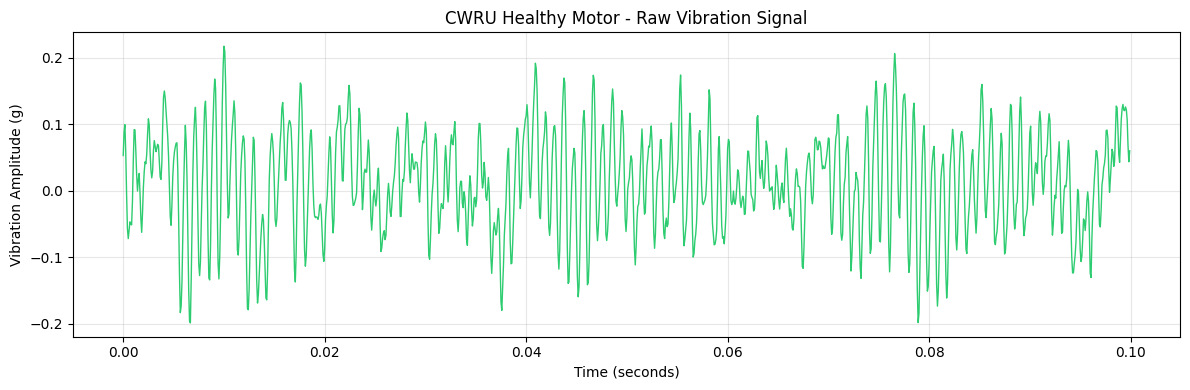

Success! Loaded 243938 samples.


In [3]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Target the first normal motor file
file_path = Path('../data/raw/normal/97.mat')

if not file_path.exists():
    print("Error: File not found. The path might be slightly off.")
else:
    # Load the MATLAB file
    mat = scipy.io.loadmat(str(file_path))
    
    # Extract the drive-end vibration signal (ignoring metadata keys)
    data_keys = [k for k in mat.keys() if not k.startswith('_')]
    signal = mat[data_keys[0]].flatten()
    
    # Create time array for 0.1 seconds (1200 samples at 12kHz)
    t = np.arange(1200) / 12000
    
    # Plot the signal
    plt.figure(figsize=(12, 4))
    plt.plot(t, signal[:1200], color='#2ecc71', linewidth=1)
    plt.xlabel('Time (seconds)')
    plt.ylabel('Vibration Amplitude (g)')
    plt.title('CWRU Healthy Motor - Raw Vibration Signal')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    # Save the figure to your reports folder
    plt.savefig('../reports/figures/day1_healthy_signal.png', dpi=150)
    plt.show()
    
    print(f"Success! Loaded {len(signal)} samples.")

In [1]:
import sys
sys.path.append('..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from src.data_loader import CWRUDataLoader

# Load all data
loader = CWRUDataLoader()
df = loader.load_dataset('../data/raw/', verbose=True)

print(f"\nDataFrame shape: {df.shape}")
print(f"\nFirst 3 rows (metadata only):")
print(df[['window_id', 'fault_type', 'severity', 'load_hp', 'source_file']].head(3))

  Loading: 100.mat [normal, 0.0", 0HP] → 236 windows
  Loading: 97.mat [normal, 0.0", 1HP] → 118 windows
  Loading: 98.mat [normal, 0.0", 2HP] → 235 windows
  Loading: 99.mat [normal, 0.0", 3HP] → 235 windows
  Loading: 105.mat [inner_race, 0.007", 0HP] → 58 windows
  Loading: 106.mat [inner_race, 0.007", 1HP] → 58 windows
  Loading: 107.mat [inner_race, 0.007", 2HP] → 58 windows
  Loading: 108.mat [inner_race, 0.007", 3HP] → 59 windows
  Loading: 169.mat [inner_race, 0.014", 0HP] → 58 windows
  Loading: 170.mat [inner_race, 0.014", 1HP] → 58 windows
  Loading: 171.mat [inner_race, 0.014", 2HP] → 58 windows
  Loading: 172.mat [inner_race, 0.014", 3HP] → 58 windows
  Loading: 209.mat [inner_race, 0.021", 0HP] → 58 windows
  Loading: 210.mat [inner_race, 0.021", 1HP] → 58 windows
  Loading: 211.mat [inner_race, 0.021", 2HP] → 58 windows
  Loading: 212.mat [inner_race, 0.021", 3HP] → 58 windows
  Loading: 130.mat [outer_race, 0.007", 0HP] → 58 windows
  Loading: 131.mat [outer_race, 0.007

normal          | RMS: 0.06664 | Peak: 0.22530 | Mean: 0.012454
inner_race      | RMS: 0.28596 | Peak: 1.48271 | Mean: 0.015576
outer_race      | RMS: 0.68004 | Peak: 3.54758 | Mean: 0.034215
ball            | RMS: 0.13722 | Peak: 0.50907 | Mean: 0.015515


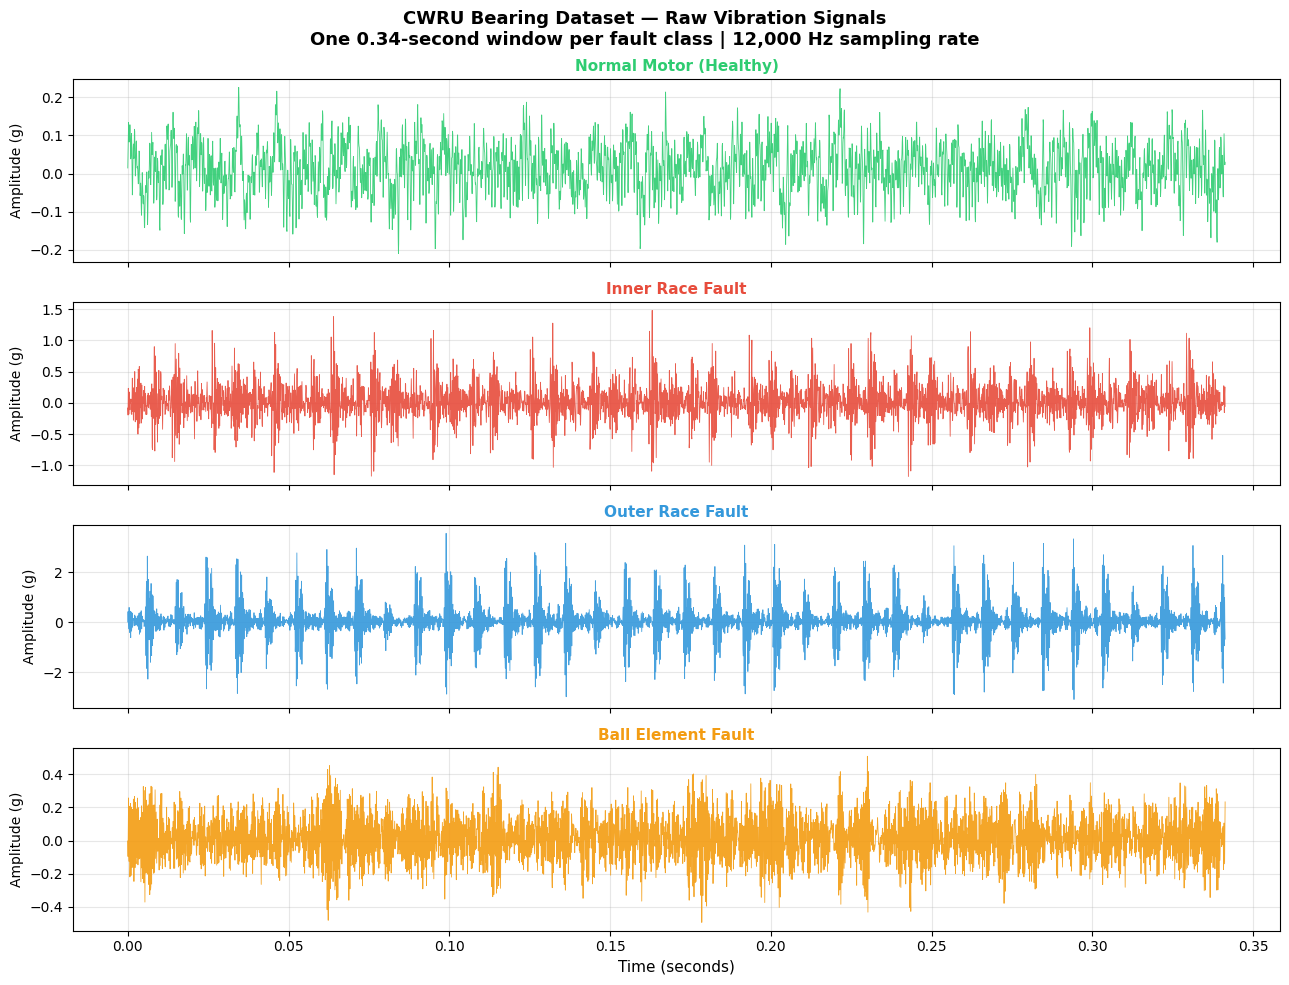


Figure saved.


In [2]:
# Colors for each fault type
COLORS = {
    'normal':      '#2ecc71',   # green  — healthy
    'inner_race':  '#e74c3c',   # red    — inner race fault
    'outer_race':  '#3498db',   # blue   — outer race fault
    'ball':        '#f39c12'    # orange — ball fault
}

TITLES = {
    'normal':      'Normal Motor (Healthy)',
    'inner_race':  'Inner Race Fault',
    'outer_race':  'Outer Race Fault',
    'ball':        'Ball Element Fault'
}

fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)

for ax, fault_type in zip(axes, COLORS.keys()):
    # Get one window from this fault class
    sample = df[df['fault_type'] == fault_type]['signal'].iloc[0]
    
    # Time axis: 4096 samples at 12kHz = 0.341 seconds
    t = np.arange(len(sample)) / 12000
    
    ax.plot(t, sample, color=COLORS[fault_type], linewidth=0.6, alpha=0.9)
    ax.set_ylabel('Amplitude (g)', fontsize=10)
    ax.set_title(TITLES[fault_type], fontsize=11, fontweight='bold', color=COLORS[fault_type])
    ax.grid(True, alpha=0.3)
    
    # Print basic stats for each class
    print(f"{fault_type:15s} | RMS: {np.sqrt(np.mean(sample**2)):.5f} | Peak: {np.max(np.abs(sample)):.5f} | Mean: {sample.mean():.6f}")

axes[-1].set_xlabel('Time (seconds)', fontsize=11)
fig.suptitle(
    'CWRU Bearing Dataset — Raw Vibration Signals\n'
    'One 0.34-second window per fault class | 12,000 Hz sampling rate',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('../reports/figures/day2_four_class_signals.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nFigure saved.")

In [2]:
import os
from pathlib import Path

print("Current folder:", os.getcwd())

target_dir = Path('../data/raw/normal/')
if target_dir.exists():
    print(f"Inside {target_dir}:", os.listdir(target_dir))
else:
    print(f"Error: The folder {target_dir} does not seem to exist relative to this notebook.")

Current folder: C:\Users\Avalokiteshwar Yadav\Desktop\motor-health-intelligence-system\notebooks
Inside ..\data\raw\normal: []


In [3]:
# How many windows per severity level?
print("Windows per fault type and severity:")
print(df.groupby(['fault_type', 'severity'])['window_id'].count())

print("\n" + "─"*50)

# What does one window look like?
sample_row = df[df['fault_type'] == 'inner_race'].iloc[0]
print(f"\nExample inner_race window:")
print(f"  window_id : {sample_row['window_id']}")
print(f"  fault_type: {sample_row['fault_type']}")
print(f"  severity  : {sample_row['severity']} inches")
print(f"  load_hp   : {sample_row['load_hp']} HP")
print(f"  label     : {sample_row['label']}")
print(f"  signal    : numpy array, shape {sample_row['signal'].shape}")
print(f"  signal[0] : {sample_row['signal'][0]:.6f}")

print("\n" + "─"*50)

# Severity distribution — how many examples per severity level?
print("\nSeverity distribution (for fault classes only):")
fault_df = df[df['fault_type'] != 'normal']
print(fault_df.groupby(['fault_type', 'severity'])['window_id']
      .count().to_string())

Windows per fault type and severity:
fault_type  severity
ball        0.007       232
            0.014       232
inner_race  0.007       233
            0.014       232
            0.021       232
normal      0.000       824
outer_race  0.007       174
            0.014       174
Name: window_id, dtype: int64

──────────────────────────────────────────────────

Example inner_race window:
  window_id : 824
  fault_type: inner_race
  severity  : 0.007 inches
  load_hp   : 0 HP
  label     : 1
  signal    : numpy array, shape (4096,)
  signal[0] : -0.083004

──────────────────────────────────────────────────

Severity distribution (for fault classes only):
fault_type  severity
ball        0.007       232
            0.014       232
inner_race  0.007       233
            0.014       232
            0.021       232
outer_race  0.007       174
            0.014       174


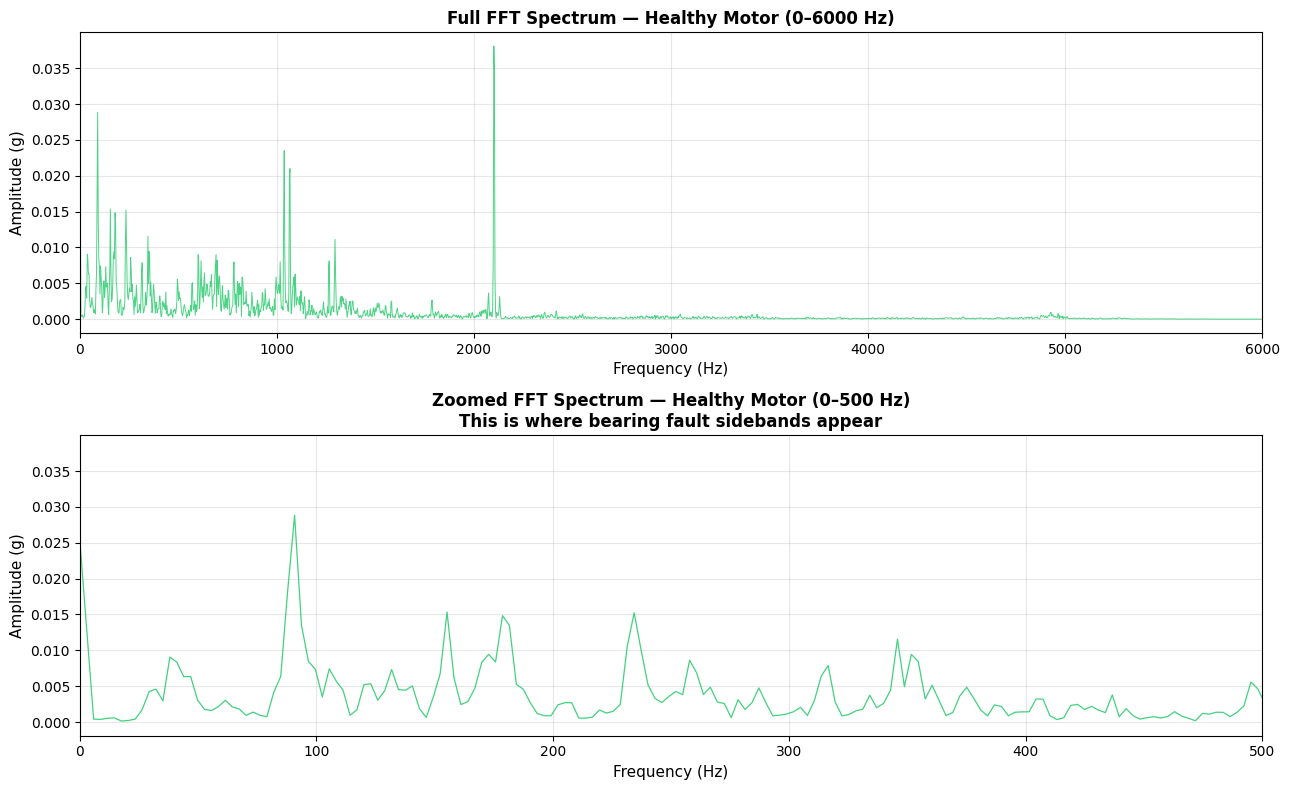

Total frequency bins: 2049
Frequency resolution: 2.930 Hz per bin
Frequency range: 0.0 – 6000.0 Hz
Peak amplitude: 0.038092 at 2100.59 Hz


In [1]:
import sys
sys.path.append('..')

import numpy as np
import matplotlib.pyplot as plt
from src.data_loader import CWRUDataLoader
from src.fft_analyzer import FFTAnalyzer

# Load data
loader   = CWRUDataLoader()
df       = loader.load_dataset('../data/raw/', verbose=False)
analyzer = FFTAnalyzer(sampling_rate=12000)

# Take one healthy motor window
healthy_signal = df[df['fault_type'] == 'normal']['signal'].iloc[0]

# Apply FFT
freqs, mags = analyzer.compute_fft(healthy_signal, apply_window=True)

# Plot
fig, axes = plt.subplots(2, 1, figsize=(13, 8))

# ── Top panel: full spectrum ──────────────────────────────────
axes[0].plot(freqs, mags, color='#2ecc71', linewidth=0.7, alpha=0.85)
axes[0].set_xlim(0, 6000)
axes[0].set_xlabel('Frequency (Hz)', fontsize=11)
axes[0].set_ylabel('Amplitude (g)', fontsize=11)
axes[0].set_title('Full FFT Spectrum — Healthy Motor (0–6000 Hz)',
                   fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# ── Bottom panel: zoomed to 0-500 Hz where faults live ────────
axes[1].plot(freqs, mags, color='#2ecc71', linewidth=0.9, alpha=0.9)
axes[1].set_xlim(0, 500)
axes[1].set_xlabel('Frequency (Hz)', fontsize=11)
axes[1].set_ylabel('Amplitude (g)', fontsize=11)
axes[1].set_title('Zoomed FFT Spectrum — Healthy Motor (0–500 Hz)\n'
                   'This is where bearing fault sidebands appear',
                   fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/day3_healthy_fft.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Print what we see
print(f"Total frequency bins: {len(freqs)}")
print(f"Frequency resolution: {freqs[1]:.3f} Hz per bin")
print(f"Frequency range: {freqs[0]:.1f} – {freqs[-1]:.1f} Hz")
print(f"Peak amplitude: {np.max(mags):.6f} at {freqs[np.argmax(mags)]:.2f} Hz")

In [2]:
# Calculate where fault peaks SHOULD appear for 1797 RPM
fault_freqs = analyzer.compute_bearing_fault_frequencies(1797)

print("Bearing fault characteristic frequencies (1797 RPM):")
print(f"  Shaft rotation  : {fault_freqs['shaft_freq']:.2f} Hz")
print(f"  BPFO (outer)    : {fault_freqs['BPFO']:.2f} Hz")
print(f"  BPFI (inner)    : {fault_freqs['BPFI']:.2f} Hz")
print(f"  BSF  (ball)     : {fault_freqs['BSF']:.2f}  Hz")
print(f"  FTF  (cage)     : {fault_freqs['FTF']:.2f}  Hz")

print("\nFor inner race fault, sidebands appear at:")
bpfi = fault_freqs['BPFI']
for n in [1, 2, 3, 4]:
    print(f"  {n} × BPFI = {n * bpfi:.2f} Hz")

print("\nFor outer race fault, sidebands appear at:")
bpfo = fault_freqs['BPFO']
for n in [1, 2, 3, 4]:
    print(f"  {n} × BPFO = {n * bpfo:.2f} Hz")

Bearing fault characteristic frequencies (1797 RPM):
  Shaft rotation  : 29.95 Hz
  BPFO (outer)    : 107.36 Hz
  BPFI (inner)    : 162.19 Hz
  BSF  (ball)     : 70.58  Hz
  FTF  (cage)     : 11.93  Hz

For inner race fault, sidebands appear at:
  1 × BPFI = 162.19 Hz
  2 × BPFI = 324.37 Hz
  3 × BPFI = 486.56 Hz
  4 × BPFI = 648.74 Hz

For outer race fault, sidebands appear at:
  1 × BPFO = 107.36 Hz
  2 × BPFO = 214.73 Hz
  3 × BPFO = 322.09 Hz
  4 × BPFO = 429.46 Hz


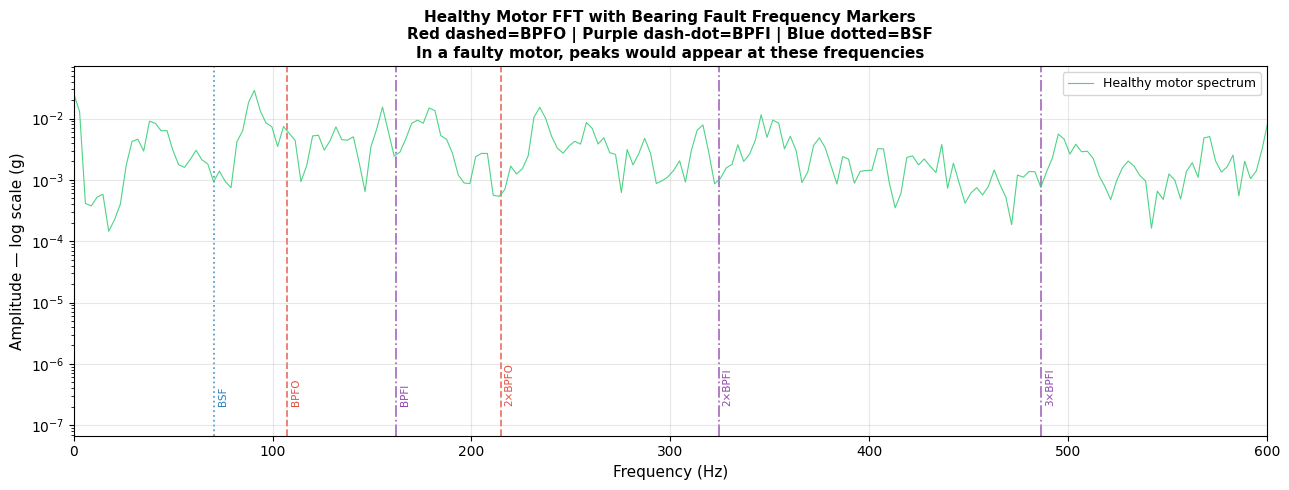

Amplitudes at fault frequencies (healthy motor):
  BPFO     at  107.4 Hz : amplitude = 0.00741759
  BPFI     at  162.2 Hz : amplitude = 0.01533832
  BSF      at   70.6 Hz : amplitude = 0.00303043
  2×BPFO   at  214.7 Hz : amplitude = 0.00270682
  2×BPFI   at  324.4 Hz : amplitude = 0.00787260
  3×BPFI   at  486.6 Hz : amplitude = 0.00557780

Note: In a FAULTY motor, these amplitudes will be
significantly higher — especially at BPFI for inner race faults.


In [3]:
# Plot the healthy spectrum with fault frequency markers
# This is your reference — what a HEALTHY motor looks like
# at the frequencies where faults would appear

fault_freq_markers = {
    'BPFO':   (fault_freqs['BPFO'],  '#e74c3c', '--'),
    'BPFI':   (fault_freqs['BPFI'],  '#8e44ad', '-.'),
    'BSF':    (fault_freqs['BSF'],   '#2980b9', ':'),
    '2×BPFO': (2*fault_freqs['BPFO'], '#e74c3c', '--'),
    '2×BPFI': (2*fault_freqs['BPFI'], '#8e44ad', '-.'),
    '3×BPFI': (3*fault_freqs['BPFI'], '#8e44ad', '-.')
}

fig, ax = plt.subplots(figsize=(13, 5))

ax.semilogy(freqs, mags,
            color='#2ecc71',
            linewidth=0.8,
            alpha=0.85,
            label='Healthy motor spectrum',
            zorder=2)

# Mark fault frequencies with vertical lines
for label, (freq, color, style) in fault_freq_markers.items():
    if freq <= 600:
        ax.axvline(x=freq,
                   color=color,
                   linestyle=style,
                   linewidth=1.3,
                   alpha=0.75,
                   zorder=1)
        ax.text(freq + 2,
                ax.get_ylim()[0] * 3,
                label,
                fontsize=7.5,
                color=color,
                rotation=90,
                va='bottom')

ax.set_xlim(0, 600)
ax.set_xlabel('Frequency (Hz)', fontsize=11)
ax.set_ylabel('Amplitude — log scale (g)', fontsize=11)
ax.set_title(
    'Healthy Motor FFT with Bearing Fault Frequency Markers\n'
    'Red dashed=BPFO | Purple dash-dot=BPFI | Blue dotted=BSF\n'
    'In a faulty motor, peaks would appear at these frequencies',
    fontsize=11, fontweight='bold'
)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../reports/figures/day3_healthy_fft_with_markers.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Measure amplitudes at fault frequencies in healthy motor
print("Amplitudes at fault frequencies (healthy motor):")
for label, (freq, _, _) in fault_freq_markers.items():
    amp = analyzer.get_amplitude_at(freqs, mags, freq, tolerance_hz=10)
    print(f"  {label:8s} at {freq:6.1f} Hz : amplitude = {amp:.8f}")

print("\nNote: In a FAULTY motor, these amplitudes will be")
print("significantly higher — especially at BPFI for inner race faults.")